
=== 재구성 오차 요약 ===
                       값
평균 재구성 오차       0.000002
표준편차            0.000010
이상치 임계값(μ+3σ)   0.000033
총 이상 샘플 수      98.000000


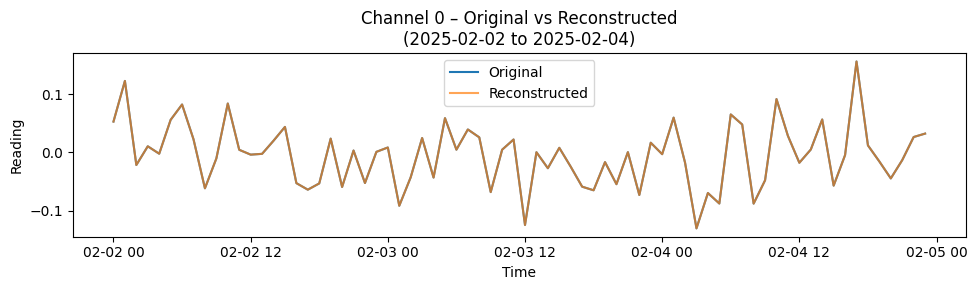

KeyError: 'anomaly_threshold'

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1) 설정 함수
# =============================================================================
def make_output_dir(path='./data'):
    os.makedirs(path, exist_ok=True)
    return path

# =============================================================================
# 2) 데이터 생성 함수
# =============================================================================
def generate_synthetic_iot(num_samples=20_000, start='2025-01-01'):
    # 시간 인덱스 (시간 단위)
    time_idx = pd.date_range(start=start, periods=num_samples, freq='h')
    
    # 잠재 요인: 일주기, 주간주기, 선형 드리프트
    t = np.linspace(0, 24*35, num_samples)
    daily  = np.stack([np.sin(2*np.pi*t/24), np.cos(2*np.pi*t/24)], axis=1)
    weekly = np.stack([np.sin(2*np.pi*t/(24*7)), np.cos(2*np.pi*t/(24*7))], axis=1)
    drift  = (t/(24*35))[:,None]
    
    # 진짜 최상위 잠재 5차원
    h_true = np.concatenate([daily, weekly, drift], axis=1)
    
    # 임의 투영으로 관측값 생성
    dims = [5, 16, 12, 8, h_true.shape[1]]
    W = [np.random.randn(dims[i], dims[i+1])*0.01 for i in range(len(dims)-1)]
    h = h_true.copy()
    for W_mat in reversed(W):
        h = h @ W_mat.T + 0.05*np.random.randn(num_samples, W_mat.shape[0])
    x = h
    
    # 이상치 삽입(15,000~15,099)
    anom = np.arange(15_000, 15_100)
    x[anom] += np.random.randn(len(anom), x.shape[1])*4
    
    return pd.DataFrame(x, index=time_idx), h_true, dims

# =============================================================================
# 3) 모델 정의, 학습, 재구성
# =============================================================================
import numpy as np

class PCLayer:
    def __init__(self, in_d, out_d):
        # 예측 가중치
        self.W = np.random.randn(in_d, out_d) * 0.01

        # BatchNorm 파라미터 초기화
        self.gamma = np.ones(out_d)
        self.beta  = np.zeros(out_d)
        self.running_mean = np.zeros(out_d)
        self.running_var  = np.ones(out_d)
        self.bn_mom = 0.9

    def batch_norm(self, h, training=True, eps=1e-5):
        # 배치 통계
        mean = h.mean(axis=0)
        var  = h.var(axis=0)

        if training:
            # 러닝 통계 업데이트
            self.running_mean = self.bn_mom * self.running_mean + (1 - self.bn_mom) * mean
            self.running_var  = self.bn_mom * self.running_var  + (1 - self.bn_mom) * var
        else:
            # 추론 시에는 학습 중 모은 통계 사용
            mean, var = self.running_mean, self.running_var

        # 정규화 및 스케일·쉬프트
        h_norm = (h - mean) / np.sqrt(var + eps)
        return self.gamma * h_norm + self.beta

    def inference(self, x, iters=100, lr_h=0.001, alpha=0.1, training=True):
        """
        상향 추론 단계
        - residual update: h_new = (1-alpha)*h_old + alpha*(err @ W) * lr_h
        - batch-norm (training=True during train(), False during reconstruct())
        """
        h = np.zeros((x.shape[0], self.W.shape[1]))
        for _ in range(iters):
            x_hat = h @ self.W.T
            err   = x - x_hat

            delta = err @ self.W
            h = (1 - alpha) * h + alpha * delta * lr_h
            # training 플래그에 따라 batch_norm 실행
            h = self.batch_norm(h, training=training)

        return h, err

    def update(self, x, h, lr=1e-5):
        """
        예측 가중치 업데이트 (Hebbian-like)
        """
        grad = (x.T @ h) / x.shape[0]
        self.W += lr * grad


class DeepPCNet:
    def __init__(self, dims):
        # dims: [input_dim, mid1, mid2, ..., latent_dim]
        self.layers = [PCLayer(dims[i], dims[i+1]) for i in range(len(dims)-1)]

    def train(self, data, epochs=60):
        """
        alternating upward inference & top-down weight updates
        """
        for epoch in range(epochs):
            latents = [data]
            # 상향 추론
            for layer in self.layers:
                h, _ = layer.inference(latents[-1])
                latents.append(h)
            # 하향 업데이트
            for i, layer in enumerate(self.layers):
                layer.update(latents[i], latents[i+1])

    def reconstruct(self, data):
        """
        1) 상향 추론으로 모든 레이어의 잠재 저장
        2) 최상위 잠재부터 하향 디코드하며 skip 연결
        """
        # 1) upward inference
        latents = [data]
        for layer in self.layers:
            h, _ = layer.inference(latents[-1], training=False)
            latents.append(h)

        # 2) downward decode + skip
        h_rec = latents[-1]
        for layer, skip in zip(reversed(self.layers), reversed(latents[:-1])):
            # W.T: (out_dim→in_dim) 투영
            h_rec = skip + (h_rec @ layer.W.T)

        return h_rec

# =============================================================================
# 4) 평가 및 요약표 생성
# =============================================================================
def evaluate_reconstruction(x_df, recon_df):
    errors = np.linalg.norm(x_df.values - recon_df.values, axis=1)
    df = x_df.copy()
    df['recon'] = recon_df.iloc[:,0]      # 채널0 예시
    df['error'] = errors
    return df

def summarize_errors(df):
    mean_e = df['error'].mean()
    std_e  = df['error'].std()
    thr    = mean_e + 3*std_e
    n_anom = (df['error'] > thr).sum()
    return pd.Series({
        '평균 재구성 오차': mean_e,
        '표준편차': std_e,
        '이상치 임계값(μ+3σ)': thr,
        '총 이상 샘플 수': n_anom
    })

# =============================================================================
# 5) Visualization Functions
# =============================================================================
def plot_signal_vs_recon(df, channel=0, window=None):
    """
    df: evaluation DataFrame
    channel: index of the original channel to compare
    window: tuple of ('YYYY-MM-DD', 'YYYY-MM-DD') for start/end date, or None
    """
    plt.figure(figsize=(10, 3))

    if window is not None:
        start, end = window
        # select only existing index range
        data = df.loc[start:end]
        if data.empty:
            print(f"⚠️ No data available for the period {start} to {end}.")
            return
    else:
        data = df

    plt.plot(data.index, data.iloc[:, channel], label='Original')
    plt.plot(data.index, data['recon'],       label='Reconstructed', alpha=0.7)
    plt.title(f'Channel {channel} – Original vs Reconstructed\n({data.index[0].date()} to {data.index[-1].date()})')
    plt.xlabel('Time')
    plt.ylabel('Reading')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_error_timeseries(df):
    """
    Plots the reconstruction error over time with the anomaly threshold.
    """
    summary = summarize_errors(df)
    threshold = summary['anomaly_threshold']
    
    plt.figure(figsize=(10, 2))
    plt.plot(df.index, df['error'], label='Error Norm')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold (μ+3σ)')
    plt.title('Reconstruction Error Time Series')
    plt.xlabel('Time')
    plt.ylabel('Error Norm')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_error_histogram(df):
    """
    Plots the distribution of reconstruction errors.
    """
    plt.figure(figsize=(6, 3))
    plt.hist(df['error'], bins=50, edgecolor='black')
    plt.title('Reconstruction Error Distribution')
    plt.xlabel('Error Norm')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 6) 실행 스크립트
# =============================================================================
if __name__ == '__main__':
    np.random.seed(42)
    out_dir = make_output_dir('./data')

    # 데이터 생성
    x_df, h_true, dims = generate_synthetic_iot()

    # 모델 학습 & 재구성
    pc = DeepPCNet(dims)
    pc.train(x_df.values, epochs=60)
    recon_vals = pc.reconstruct(x_df.values)
    recon_df = pd.DataFrame(recon_vals, index=x_df.index, columns=[f'ch{i}' for i in range(recon_vals.shape[1])])

    # 평가
    df_eval = evaluate_reconstruction(x_df, recon_df)
    summary = summarize_errors(df_eval)
    print('\n=== 재구성 오차 요약 ===')
    print(summary.to_frame('값'))

    # 시각화
    plot_signal_vs_recon(df_eval, channel=0, window=('2025-02-02','2025-02-04'))
    plot_error_timeseries(df_eval)
    plot_error_histogram(df_eval)
